In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("insurance.csv")
df.head(4)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [19]:
df['smoker'].value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

#### Data Preprocessing

In [6]:
# Encode categorical variables
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])        # male/female → 0/1
df['smoker'] = le.fit_transform(df['smoker'])  # yes/no → 1/0
df['region'] = le.fit_transform(df['region'])  # region categories

#### Feature Selection

In [7]:
X = df.drop('charges', axis=1)  # independent variables
y = df['charges']               # target variable

#### Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

#### Train Linear Regression Model

In [9]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [18]:
model.predict([[18,	1,	33.770,	1,	0,	2]])

C:\Users\AKE\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3883.47859645])

#### Predictions

In [10]:
y_pred = model.predict(X_test)

#### Model Evaluation

In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4186.508898366434
RMSE: 5799.587091438356


#### Visualizations

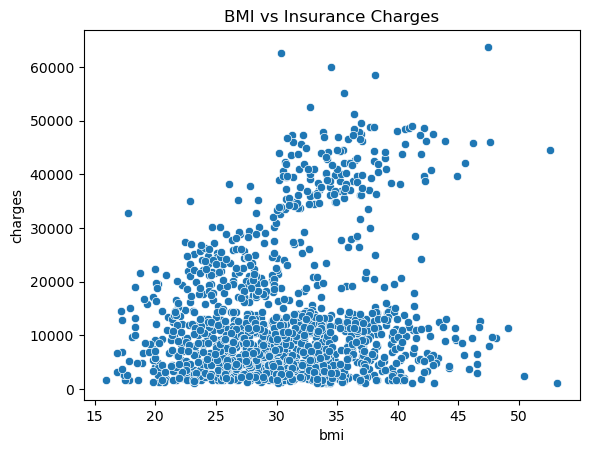

In [12]:
# BMI vs Charges
plt.figure()
sns.scatterplot(x=df['bmi'], y=df['charges'])
plt.title("BMI vs Insurance Charges")
plt.show()

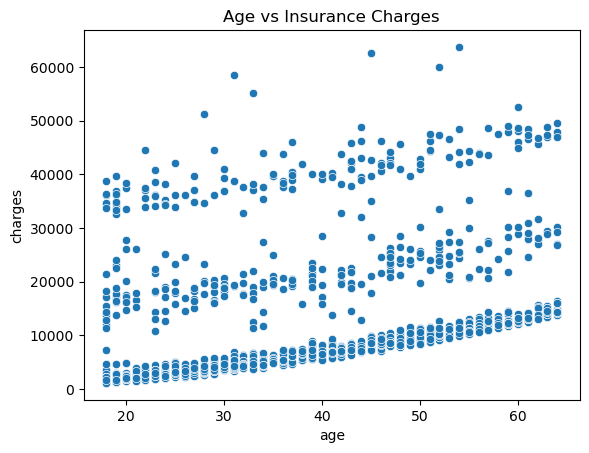

In [13]:
# Age vs Charges
plt.figure()
sns.scatterplot(x=df['age'], y=df['charges'])
plt.title("Age vs Insurance Charges")
plt.show()

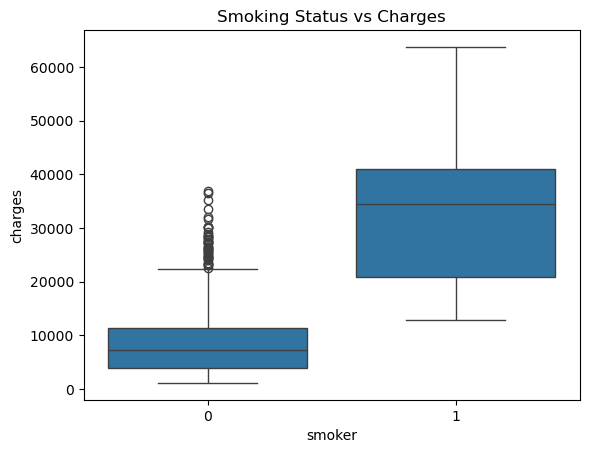

In [14]:
# Smoking vs Charges
plt.figure()
sns.boxplot(x=df['smoker'], y=df['charges'])
plt.title("Smoking Status vs Charges")
plt.show()